In [25]:
from pathlib import Path
import pandas as pd

source = Path("/media/storage/gepner/derivatives/kepost")

In [26]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [27]:
data = []
for fname in source.glob("sub-*/ses-*/dwi/software-mrtrix3/subtype-parcellations/atlas-schaefer2018tian2020_div-7networks_den-400/sub-*_ses-*_acq-shell1000_space-MNI152NLin2009cAsym_atlas-schaefer2018tian2020_div-7networks_den-400_meas-adc_parc.pkl"):
    subj_df = pd.read_pickle(fname)
    data.append(subj_df)
df = pd.concat(data)

In [28]:
# keep only subject_codes with more than 1 session
s = df.drop_duplicates(subset=["subject_code", "session_id"],keep="first")
counts = s["subject_code"].value_counts()
keep = counts[counts > 1].index
df = df[df["subject_code"].isin(keep)]

# prepare to t test
df = df.sort_values(by=["subject_code", "session_id"])
before = df.groupby(["index","subject_code"]).first().reset_index()
after = df.groupby(["index","subject_code"]).last().reset_index()

In [29]:
from scipy.stats import ttest_rel

dist_measure = "qfmean"

stats = parcels.copy()

for i,row in parcels.iterrows():
    roi = row[region_col]
    before_roi = before[before[region_col] == roi][dist_measure].values
    after_roi = after[after[region_col] == roi][dist_measure].values
    if len(before_roi) == 0 or len(after_roi) == 0:
        continue
    t_stat, p_val = ttest_rel(after_roi,before_roi)
    stats.loc[i, "t_stat"] = t_stat
    stats.loc[i, "p_val"] = p_val
    

In [30]:
from statsmodels.stats.multitest import multipletests
stats["pval_adj"] = multipletests(stats["p_val"], method="fdr_bh")[1]

<Axes: xlabel='tag', ylabel='qfmean'>

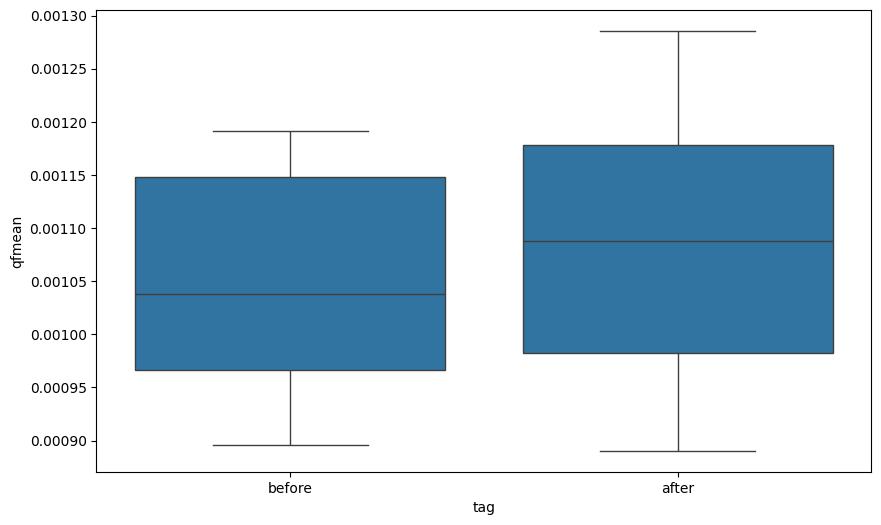

In [31]:
most_significant = stats.sort_values(by="p_val").index[0]
roi = parcels.loc[most_significant, region_col]
d = before[before[region_col] == roi][[dist_measure]]
d["tag"] = "before"
d2 = after[after[region_col] == roi][[dist_measure]]
d2["tag"] = "after"
d = pd.concat([d, d2])
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.boxplot(data=d, x="tag", y=dist_measure)

In [32]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation
import nibabel as nib


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["veryinflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

In [33]:
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}


vis_df = stats.copy()
p_column = "p_val"
value_column = "t_stat"

value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
        value = row[value_column]
    else:
        value = np.nan  # Set to NaN if not significant or below value_threshold

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

In [34]:
# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)

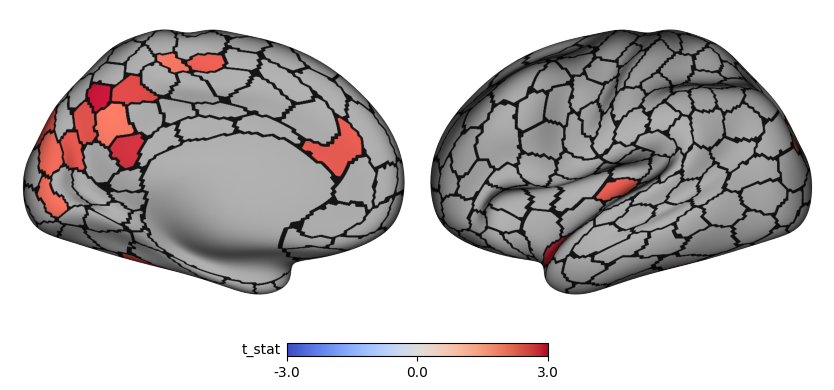

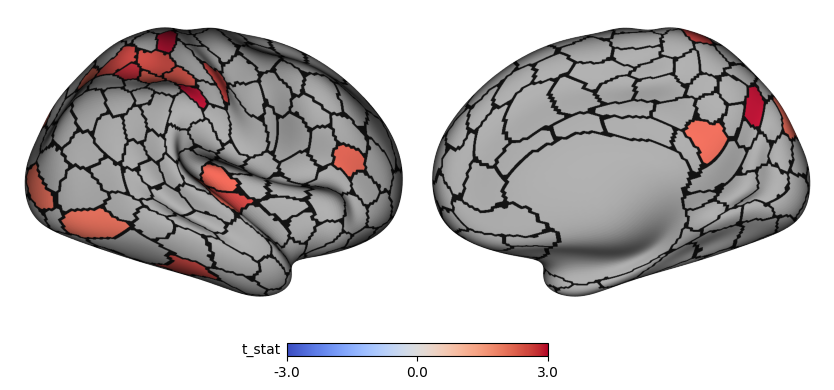

In [35]:
vmin = -3
vmax = 3


# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]

    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap="coolwarm",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    savefig_nice(
        fig,
        f"/home/galkepler/Downloads/gepner_{hemi_key}_cort_t.png",
        tight=True,
        dpi=300,
    )

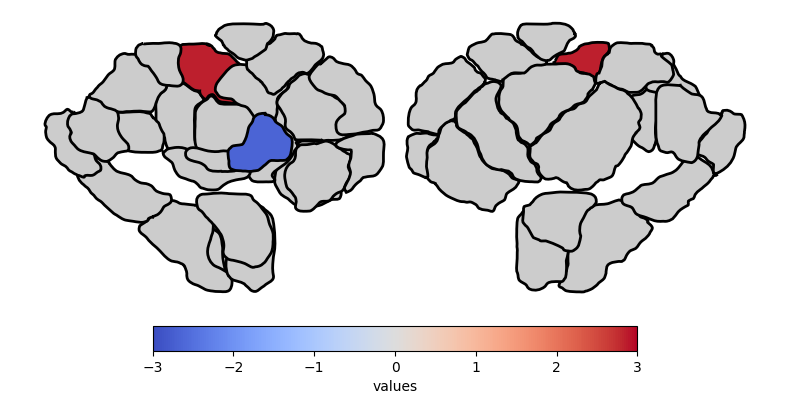

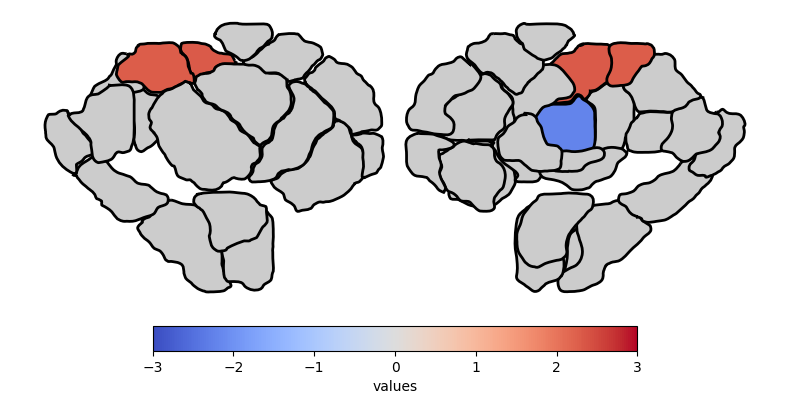

In [36]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap="coolwarm",
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    savefig_nice(
        fig,
        
        f"/home/galkepler/Downloads/subcortical_{hemi}_t.png",
        tight=True,
        dpi=300,
    )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)